# **Phase 0**

In [ ]:
# Charger le fichier CSV dans un DataFrame

import pandas as pd

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('adult.csv')

df.head()

Saving adult.csv to adult.csv


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
df.shape

(32561, 15)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df['income'].value_counts(normalize=True)

,proportion
income,
<=50K,0.75919
>50K,0.24081


In [ ]:
# Nettoyage obligatoire (transformer les “?” en NA)

df = df.replace("?", pd.NA)
df.isna().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0


In [ ]:
# Imputation par catégorie "Unknown"

for col in ['workclass','occupation','native.country']:
    df[col] = df[col].fillna("Unknown")

# Nettoyage des noms et valeurs

df.columns = [c.replace(".", "_") for c in df.columns]

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

In [ ]:
df.isna().sum()
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,90,Unknown,77053,HS-grad,9,Widowed,Unknown,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Unknown,186061,Some-college,10,Widowed,Unknown,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


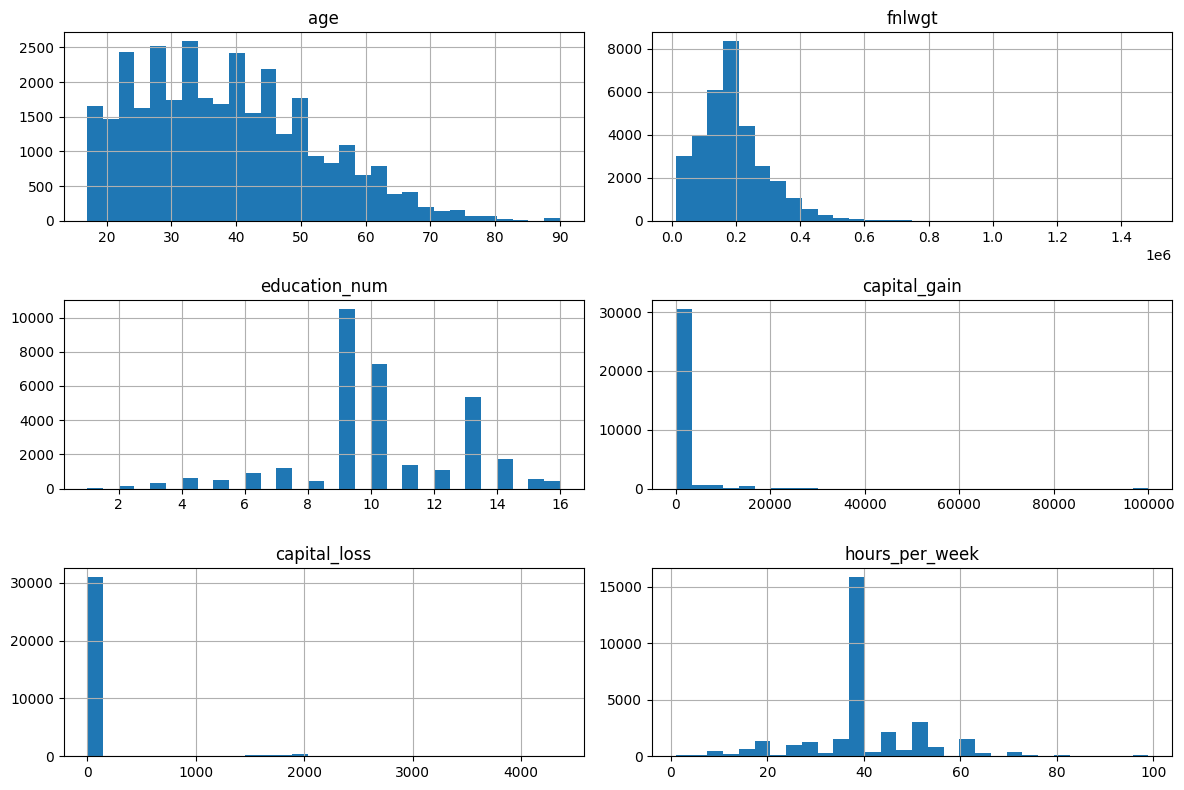

In [ ]:
# Distributions des variables numériques

import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['age','fnlwgt','education_num','capital_gain','capital_loss','hours_per_week']

df[num_cols].hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

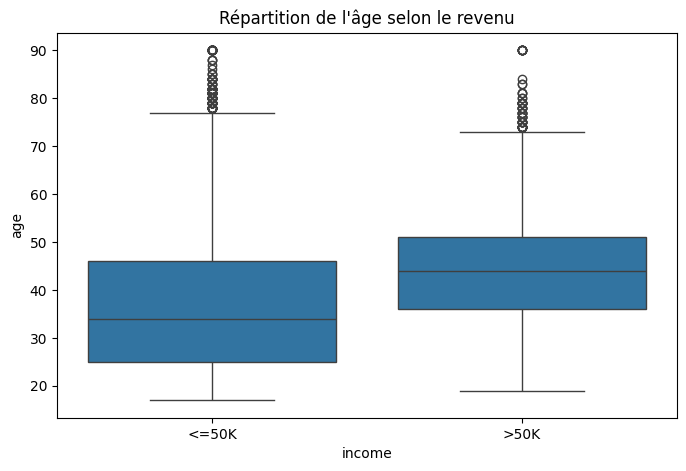

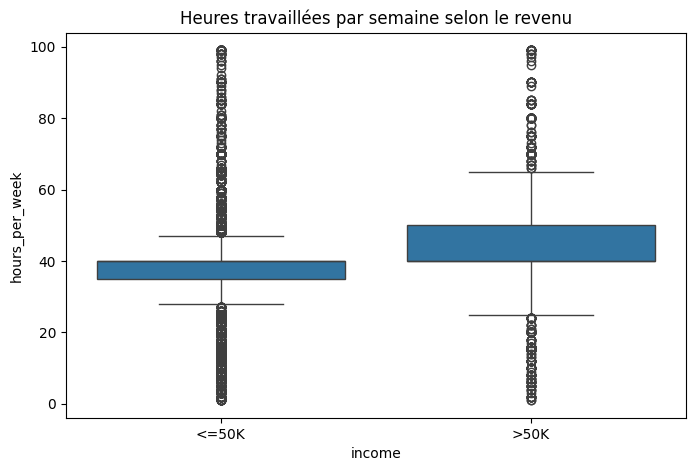

In [ ]:
# Distribution de la cible vs âge, heures/semaine (exemples)

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='income', y='age')
plt.title("Répartition de l'âge selon le revenu")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='income', y='hours_per_week')
plt.title("Heures travaillées par semaine selon le revenu")
plt.show()

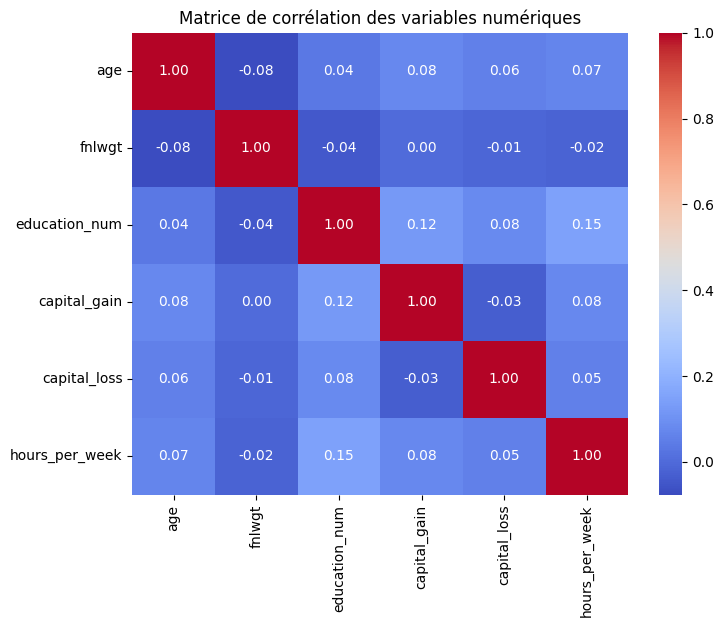

In [ ]:
# Corrélation des variables numériques

plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation des variables numériques")
plt.show()

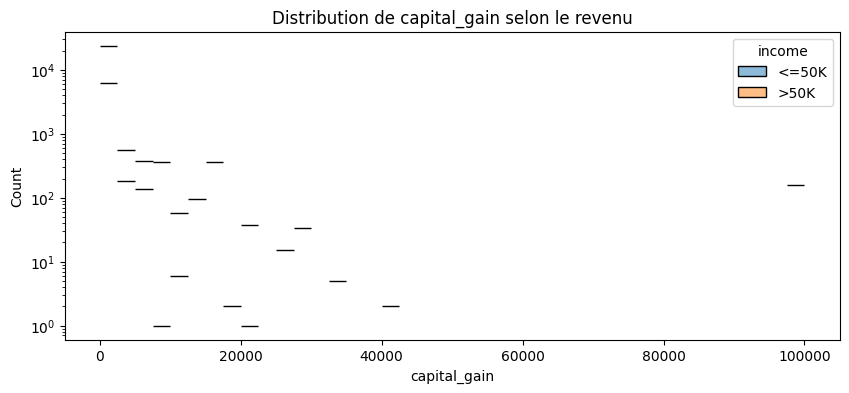

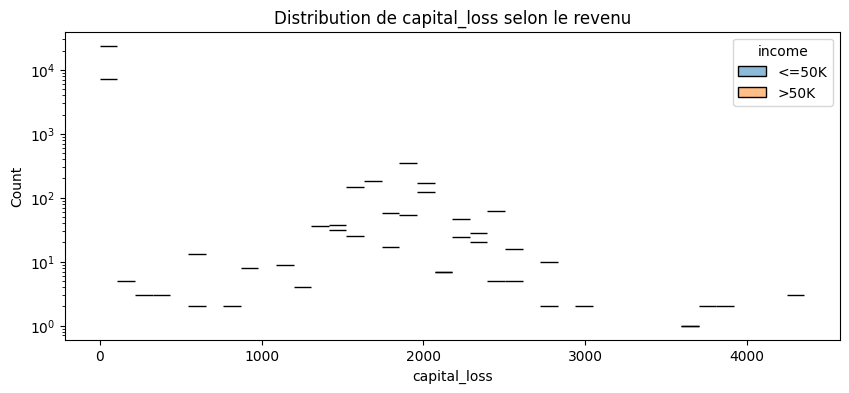

In [ ]:
# Analyse ciblée capital_gain / capital_loss

plt.figure(figsize=(10,4))
sns.histplot(df, x='capital_gain', hue='income', bins=40, log_scale=(False, True))
plt.title("Distribution de capital_gain selon le revenu")
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(df, x='capital_loss', hue='income', bins=40, log_scale=(False, True))
plt.title("Distribution de capital_loss selon le revenu")
plt.show()

# **Phase 1**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
# Préparation du preprocessing (pipeline)

num_cols = ['age','fnlwgt','education_num','capital_gain','capital_loss','hours_per_week']
cat_cols = [col for col in df.columns if df[col].dtype == 'object' and col != 'income']

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

In [ ]:
# Fonction générique pour tracer les learning curves

def plot_learning_curves(estimator, title):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    train_sizes, train_scores, val_scores = learning_curve(
        estimator,
        df.drop("income", axis=1),
        df["income"],
        cv=cv,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 8),
        scoring="accuracy"
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)

    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    plt.figure(figsize=(10,6))
    plt.title(title)
    plt.plot(train_sizes, train_mean, label="Train score", marker='o')
    plt.plot(train_sizes, val_mean, label="Validation score", marker='o')
    plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15)
    plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15)
    plt.xlabel("Taille de l'échantillon d'entraînement")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

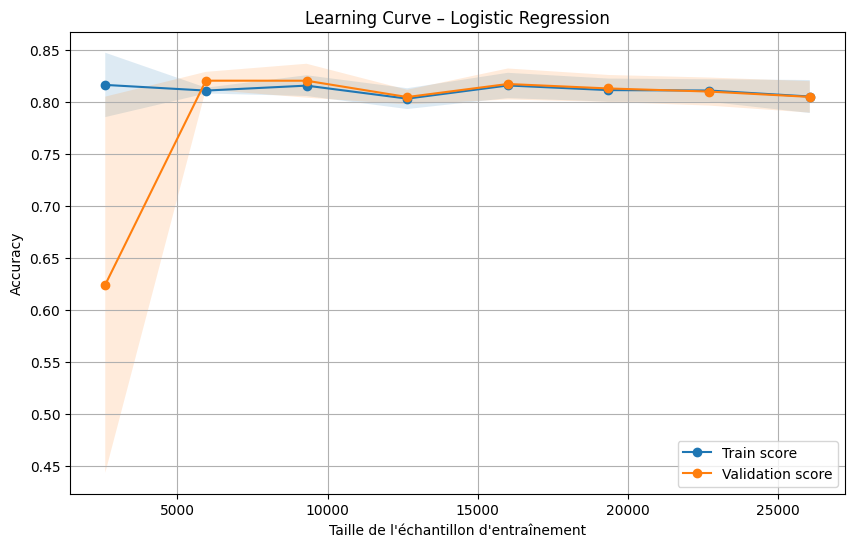

In [ ]:
# Modèle baseline (Logistic Regression)

baseline_model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=200))
])

plot_learning_curves(baseline_model, "Learning Curve – Logistic Regression")

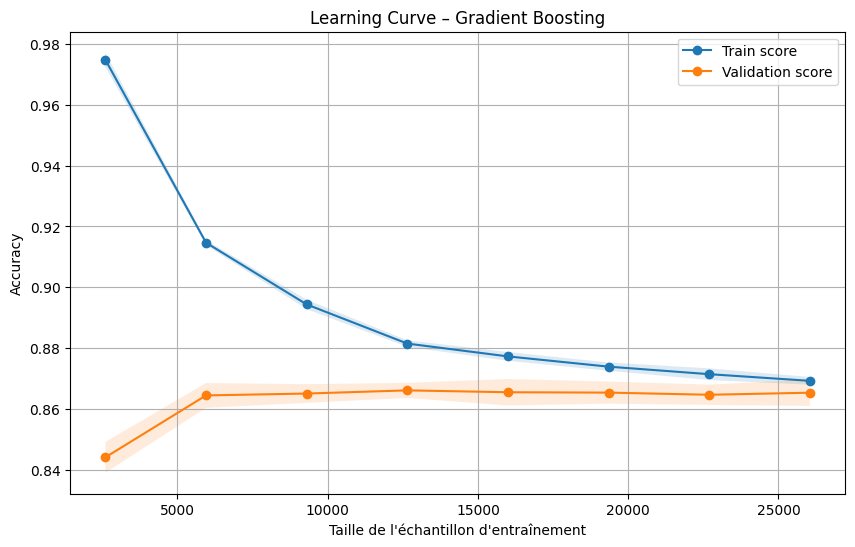

In [ ]:
# Modèle principal (Gradient Boosting)

gb_model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

plot_learning_curves(gb_model, "Learning Curve – Gradient Boosting")

# **Phase 2**

In [ ]:
X = df.drop("income", axis=1)
y = df["income"]

In [ ]:
# Validation croisée stratifiée (5-fold)

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    gb_model,  # ton modèle pipeline Gradient Boosting
    X, y,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("Scores CV :", cv_scores)
print("Moyenne :", cv_scores.mean())
print("Écart-type :", cv_scores.std())


Scores CV : [0.86304314 0.86256143 0.86041155 0.870086   0.87100737]
Moyenne : 0.8654218967093218
Écart-type : 0.00428708973762965


In [ ]:
# Bootstrap (100 ou 200 rééchantillonnages)

import numpy as np
from sklearn.metrics import accuracy_score

n_bootstrap = 100
bootstrap_scores = []

np.random.seed(42)

for _ in range(n_bootstrap):
    # tirer un échantillon bootstrap
    sample_idx = np.random.choice(len(X), size=len(X), replace=True)
    X_boot = X.iloc[sample_idx]
    y_boot = y.iloc[sample_idx]

    # train / test interne bootstrap (20% out-of-bag)
    test_mask = np.ones(len(X), dtype=bool)
    test_mask[sample_idx] = False

    X_oob = X.iloc[test_mask]
    y_oob = y.iloc[test_mask]

    gb_model.fit(X_boot, y_boot)
    preds = gb_model.predict(X_oob)

    bootstrap_scores.append(accuracy_score(y_oob, preds))

bootstrap_scores = np.array(bootstrap_scores)
print("Bootstrap mean :", bootstrap_scores.mean())
print("Bootstrap std :", bootstrap_scores.std())


Bootstrap mean : 0.8654837820311171
Bootstrap std : 0.0029306611315274957


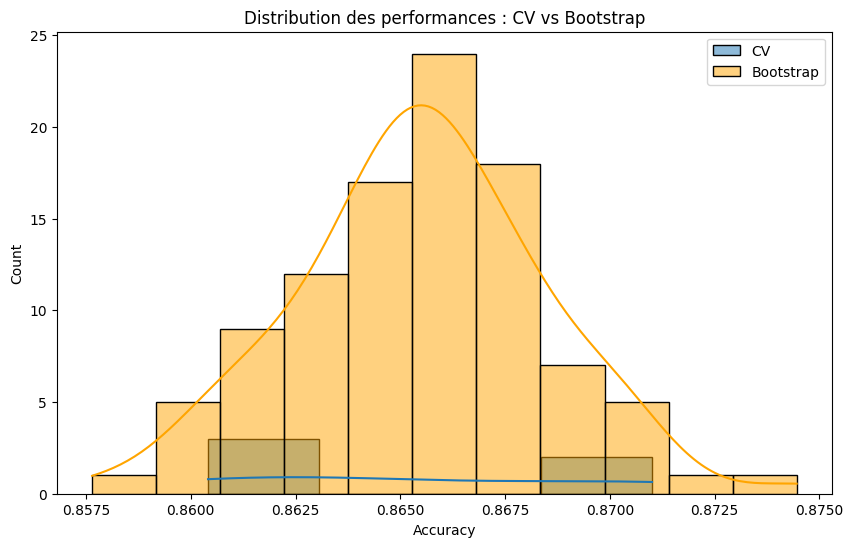

In [ ]:
# Visualisation de la distribution des scores (CV vs Bootstrap)

plt.figure(figsize=(10,6))
sns.histplot(cv_scores, label="CV", kde=True)
sns.histplot(bootstrap_scores, label="Bootstrap", kde=True, color="orange")
plt.legend()
plt.title("Distribution des performances : CV vs Bootstrap")
plt.xlabel("Accuracy")
plt.show()

# **Phase 3**

In [ ]:
# Définir l’espace de recherche et justifier les bornes

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_distributions = {
    "classifier__n_estimators": randint(50, 400),
    "classifier__learning_rate": uniform(0.01, 0.3),
    "classifier__max_depth": randint(2, 6),
    "classifier__subsample": uniform(0.7, 0.3)
}

In [ ]:
# RandomizedSearchCV

random_search = RandomizedSearchCV(
    gb_model,
    param_distributions=param_distributions,
    n_iter=30,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X, y)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['workclass',
                                                                                'education',
                                                                                'marital_status',
                                                                                'occupation',
                                                                                'relationship',
                                                                                'race',
                                                                                'sex',
                                                                                'native_country']),
                                                                              ('num',
                                                                               'passthrough',
                                                                               ['age',
                                                                                'fnlwgt',
                                                                                'education_num',
                                                                                'capital_gain',
                                                                                'capital_loss',
                                                                                'hours_per_week'])])...
                                        'classifier__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78defba44980>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78df01614530>,
                                        'classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x78df0027a030>},
                   random_state=42, scoring='accuracy', verbose=2)

In [ ]:
# Afficher les meilleurs hyperparamètres

print("Meilleurs hyperparamètres :")
print(random_search.best_params_)

print("Meilleure performance CV :", random_search.best_score_)

Meilleurs hyperparamètres :
{'classifier__learning_rate': np.float64(0.06545633665765811), 'classifier__max_depth': 4, 'classifier__n_estimators': 267, 'classifier__subsample': np.float64(0.8349262400109296)}
Meilleure performance CV : 0.8124758987034436


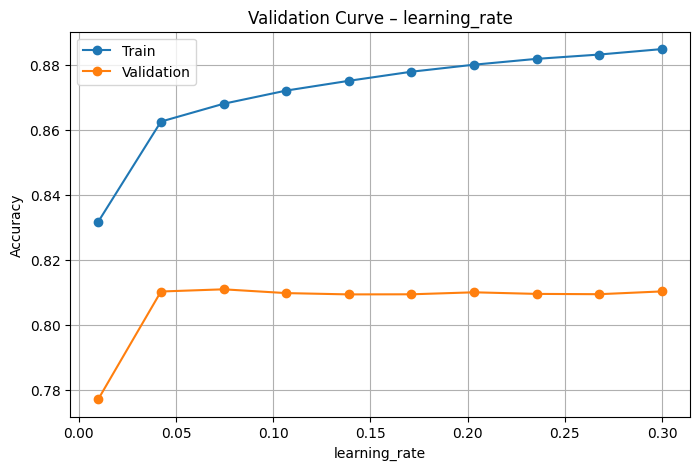

In [ ]:
# Validation curves pour 2 hyperparamètres majeurs

from sklearn.model_selection import validation_curve
import numpy as np

# 1. learning_rate
param_range = np.linspace(0.01, 0.3, 10)

train_scores, val_scores = validation_curve(
    gb_model,
    X, y,
    param_name="classifier__learning_rate",
    param_range=param_range,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(param_range, train_mean, marker="o", label="Train")
plt.plot(param_range, val_mean, marker="o", label="Validation")
plt.title("Validation Curve – learning_rate")
plt.xlabel("learning_rate")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

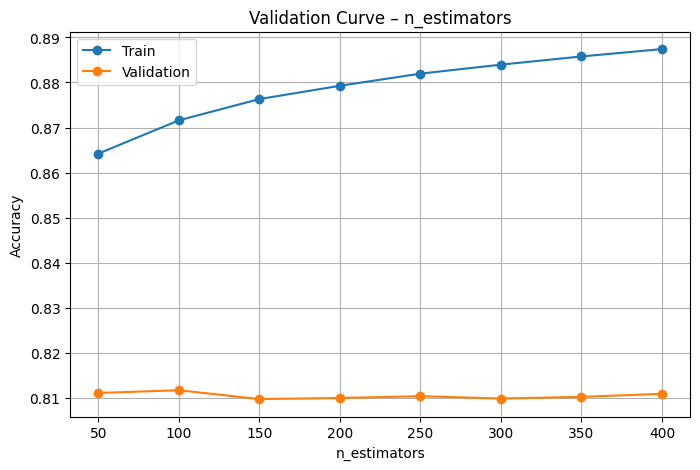

In [ ]:
# 2. n_estimators
param_range = [50, 100, 150, 200, 250, 300, 350, 400]

train_scores, val_scores = validation_curve(
    gb_model,
    X, y,
    param_name="classifier__n_estimators",
    param_range=param_range,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(param_range, train_mean, marker="o", label="Train")
plt.plot(param_range, val_mean, marker="o", label="Validation")
plt.title("Validation Curve – n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Réévaluation du meilleur modèle sur plusieurs splits

best_model = random_search.best_estimator_

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_val_score(best_model, X, y, cv=cv, scoring="accuracy", n_jobs=-1)

print("Scores :", scores)
print("Moyenne :", scores.mean())
print("Écart-type :", scores.std())

Scores : [0.86766963 0.86977887 0.86732187 0.87469287 0.86640049 0.86486486
 0.8713145  0.87837838 0.879914   0.8762285 ]
Moyenne : 0.8716563983527447
Écart-type : 0.005055406359803341


# **Phase 4**

In [ ]:
# Préparation d'un train / test propre

from sklearn.model_selection import train_test_split

X = df.drop("income", axis=1)
y = df["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

best_model = random_search.best_estimator_
best_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['workclass', 'education',
                                                   'marital_status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native_country']),
                                                 ('num', 'passthrough',
                                                  ['age', 'fnlwgt',
                                                   'education_num',
                                                   'capital_gain',
                                                   'capital_loss',
                                                   'hours_per_week'])])),
                ('classifier',
                 GradientBoostingClassifier(learning_rate=np.float64(0.06545633665765811),
                                            max_depth=4, n_estimators=267,
                                            random_state=42,
                                            subsample=np.float64(0.8349262400109296)))])

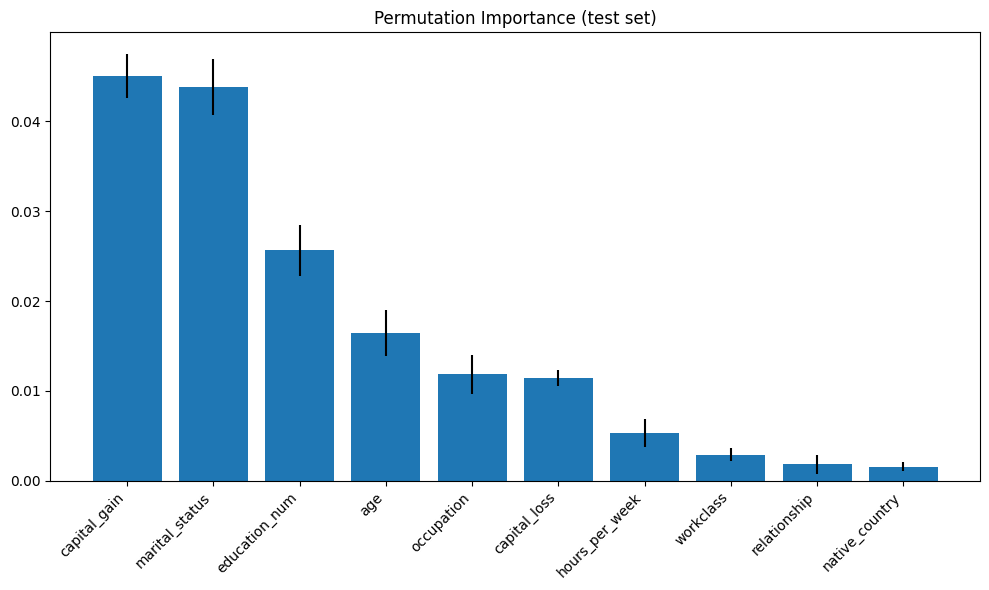

In [ ]:
# Permutation Importance (globale)

from sklearn.inspection import permutation_importance
import numpy as np
import matplotlib.pyplot as plt

result = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importances = result.importances_mean
std = result.importances_std
feature_names = X.columns

indices = np.argsort(importances)[::-1]  # tri décroissant

plt.figure(figsize=(10,6))
plt.title("Permutation Importance (test set)")
plt.bar(range(10), importances[indices][:10], yerr=std[indices][:10])
plt.xticks(range(10), feature_names[indices][:10], rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# SHAP – importance globale + dépendances

!pip install shap

In [ ]:
import shap

# Récupérer le préprocesseur et le modèle
preprocess = best_model.named_steps["preprocessing"]
gb_clf = best_model.named_steps["classifier"]

# Transformer X_test dans l’espace numérique et le convertir en tableau dense
X_test_trans = preprocess.transform(X_test).toarray().astype(float)

# Get feature names for SHAP plots
cat_feature_names_out = preprocess.named_transformers_['cat'].get_feature_names_out(cat_cols)
shap_feature_names = list(cat_feature_names_out) + num_cols

explainer = shap.TreeExplainer(gb_clf)
shap_values = explainer.shap_values(X_test_trans)

/tmp/ipython-input-3461556268.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_trans, feature_names=shap_feature_names)


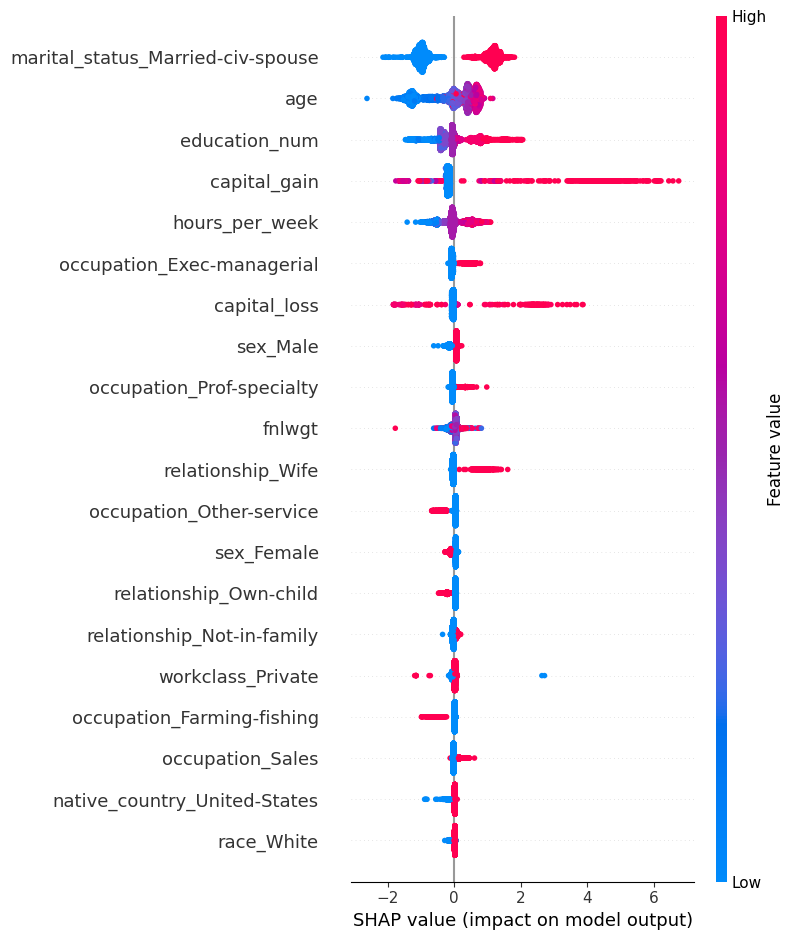

In [ ]:
shap.summary_plot(shap_values, X_test_trans, feature_names=shap_feature_names)

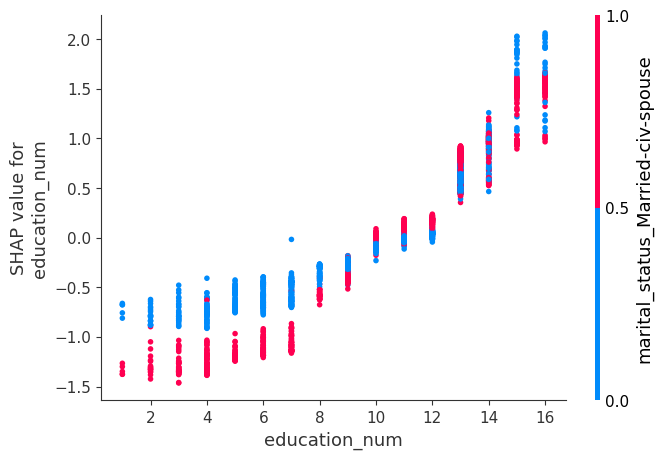

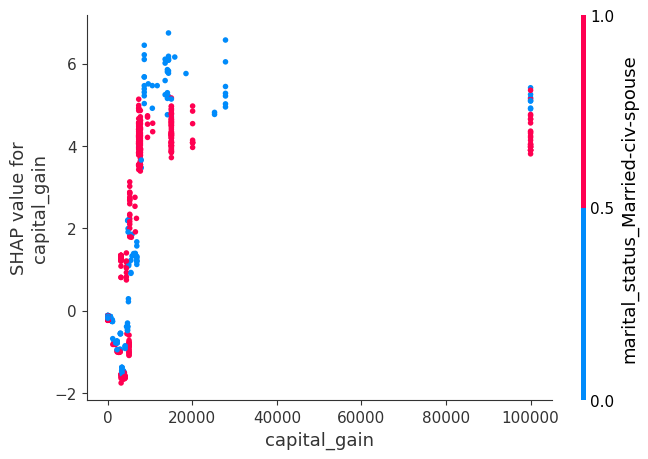

In [ ]:
shap.dependence_plot(
    "education_num",
    shap_values, X_test_trans, feature_names=shap_feature_names
)

shap.dependence_plot(
    "capital_gain",
    shap_values, X_test_trans, feature_names=shap_feature_names
)

In [ ]:
# Explications locales

shap.initjs()

idx1, idx2 = 0, 1  # ou d'autres indices

shap.force_plot(
    explainer.expected_value,
    shap_values[idx1,:],
    X_test_trans[idx1,:],
    feature_names=shap_feature_names
)

# **Phase 5**

In [ ]:
# Rappel : train / test et modèle

from sklearn.model_selection import train_test_split

X = df.drop("income", axis=1)
y = df["income"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

best_model = random_search.best_estimator_
best_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['workclass', 'education',
                                                   'marital_status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native_country']),
                                                 ('num', 'passthrough',
                                                  ['age', 'fnlwgt',
                                                   'education_num',
                                                   'capital_gain',
                                                   'capital_loss',
                                                   'hours_per_week'])])),
                ('classifier',
                 GradientBoostingClassifier(learning_rate=np.float64(0.06545633665765811),
                                            max_depth=4, n_estimators=267,
                                            random_state=42,
                                            subsample=np.float64(0.8349262400109296)))])

In [ ]:
# Création d'un jeu drifté à partir de X_test

# On va simuler un contexte “plus jeune, plus précaire” :
# age : population plus jeune (–8 ans en moyenne)
# hours_per_week : moins d’heures travaillées
# marital_status : plus de “Never-married”, moins de “Married-civ-spouse”
# occupation : plus de “Other-service” (secteur moins rémunérateur)

import numpy as np

X_test_drift = X_test.copy()

# 1) Population plus jeune
X_test_drift["age"] = (X_test_drift["age"] - 8).clip(lower=18)

# 2) Moins d'heures travaillées
X_test_drift["hours_per_week"] = (X_test_drift["hours_per_week"] * 0.8).clip(lower=1)

# 3) Plus de célibataires : transformer une partie des mariés en "Never-married"
mask_married = X_test_drift["marital_status"] == "Married-civ-spouse"
mask_change = mask_married & (np.random.rand(len(X_test_drift)) < 0.4)
X_test_drift.loc[mask_change, "marital_status"] = "Never-married"

# 4) Plus de services : transformer une partie des occupations en "Other-service"
mask_occ = np.random.rand(len(X_test_drift)) < 0.3
X_test_drift.loc[mask_occ, "occupation"] = "Other-service"

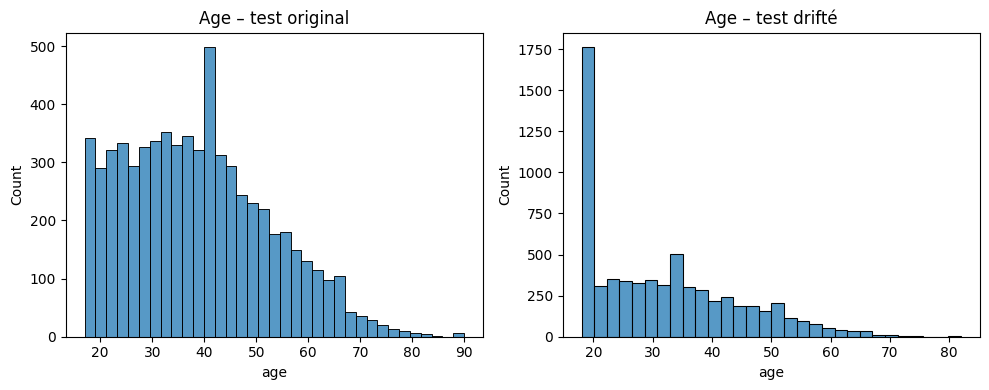

In [ ]:
# Visualisation avant / après

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.histplot(X_test["age"], kde=False, ax=axes[0])
axes[0].set_title("Age – test original")
sns.histplot(X_test_drift["age"], kde=False, ax=axes[1])
axes[1].set_title("Age – test drifté")
plt.tight_layout()
plt.show()

In [ ]:
# Mesure du drift (KS, chi², Wasserstein, JSD, PSI)

# Fonctions utilitaires

from scipy.stats import ks_2samp, chi2_contingency, wasserstein_distance, entropy

def psi_num(ref, cur, n_bins=10):
    """Population Stability Index pour une variable numérique."""
    ref = np.asarray(ref)
    cur = np.asarray(cur)

    # bins basés sur le ref (quantiles)
    quantiles = np.linspace(0, 1, n_bins + 1)
    bins = np.unique(np.quantile(ref, quantiles))
    # si bins non uniques (variable constante), PSI=0
    if len(bins) <= 2:
        return 0.0

    ref_counts, _ = np.histogram(ref, bins=bins)
    cur_counts, _ = np.histogram(cur, bins=bins)

    ref_perc = ref_counts / ref_counts.sum()
    cur_perc = cur_counts / cur_counts.sum()

    # éviter les 0
    ref_perc = np.where(ref_perc == 0, 1e-6, ref_perc)
    cur_perc = np.where(cur_perc == 0, 1e-6, cur_perc)

    return np.sum((ref_perc - cur_perc) * np.log(ref_perc / cur_perc))

def jsd(p, q):
    """Jensen–Shannon divergence entre deux distributions (p, q)."""
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    p /= p.sum()
    q /= q.sum()
    m = 0.5 * (p + q)
    return 0.5 * (entropy(p, m, base=2) + entropy(q, m, base=2))

In [ ]:
# Drift pour variables numériques

num_cols = ['age','fnlwgt','education_num','capital_gain','capital_loss','hours_per_week']

import pandas as pd

rows_num = []
for col in num_cols:
    ref = X_test[col]
    cur = X_test_drift[col]

    ks = ks_2samp(ref, cur).statistic
    w = wasserstein_distance(ref, cur)
    psi = psi_num(ref, cur)

    rows_num.append({
        "feature": col,
        "KS": ks,
        "Wasserstein": w,
        "PSI": psi
    })

drift_num_df = pd.DataFrame(rows_num)
drift_num_df

,feature,KS,Wasserstein,PSI
0,age,0.210041,7.121910,0.347612
1,fnlwgt,0.000000,0.000000,0.000000
2,education_num,0.000000,0.000000,0.000000
3,capital_gain,0.000000,0.000000,0.000000
4,capital_loss,0.000000,0.000000,0.000000
5,hours_per_week,0.559803,8.100814,1.982963


In [ ]:
# Drift pour variables catégorielles

# On utilise chi² + JSD sur les distributions de fréquences

cat_cols = ['marital_status', 'occupation', 'workclass', 'native_country']

rows_cat = []
for col in cat_cols:
    ref_counts = X_test[col].value_counts().sort_index()
    cur_counts = X_test_drift[col].value_counts().sort_index()

    # aligner les catégories
    all_idx = ref_counts.index.union(cur_counts.index)
    ref_counts = ref_counts.reindex(all_idx, fill_value=0)
    cur_counts = cur_counts.reindex(all_idx, fill_value=0)

    table = np.vstack([ref_counts.values, cur_counts.values])
    chi2, p, dof, exp = chi2_contingency(table)

    js = jsd(ref_counts.values, cur_counts.values)

    rows_cat.append({
        "feature": col,
        "chi2": chi2,
        "JSD": js
    })

drift_cat_df = pd.DataFrame(rows_cat)
drift_cat_df

,feature,chi2,JSD
0,marital_status,559.516318,0.031277
1,occupation,1364.033204,0.079340
2,workclass,0.000000,0.000000
3,native_country,0.000000,0.000000


In [ ]:
# Impact du drift sur les performances

from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, roc_auc_score

# Prédictions sur le test original
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1]

# Prédictions sur le test drifté
y_pred_drift = best_model.predict(X_test_drift)
y_proba_drift = best_model.predict_proba(X_test_drift)[:, 1]

# Binaire pour ROC-AUC
y_bin = (y_test == ">50K").astype(int)

def metrics_report(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, pos_label=">50K"),
        "roc_auc": roc_auc_score(y_bin, y_proba),
    }

metrics_orig = metrics_report(y_test, y_pred_test, y_proba_test)
metrics_drift = metrics_report(y_test, y_pred_drift, y_proba_drift)

print("Performances sur test original :", metrics_orig)
print("Performances sur test drifté   :", metrics_drift)

Performances sur test original : {'accuracy': 0.8665745432212498, 'balanced_acc': np.float64(0.7886605337281525), 'f1': 0.6973180076628352, 'roc_auc': np.float64(0.9223844947483544)}
Performances sur test drifté   : {'accuracy': 0.826654383540611, 'balanced_acc': np.float64(0.6545775210994408), 'f1': 0.47267631947687994, 'roc_auc': np.float64(0.8767833283465054)}


# **Phase 6**

In [ ]:
# Variables fortement driftées à supprimer

drifted_vars = ["hours_per_week", "age", "marital_status", "occupation"]

## **Stratégie 1 - Suppression des variables fortement driftées**

In [ ]:
# Construction d'un pipeline sans ces variables

X_nodrift = X.drop(columns=drifted_vars)

X_train_nd, X_test_nd, _, _ = train_test_split(
    X_nodrift, y, test_size=0.2, stratify=y, random_state=42
)

preproc_nd = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"),
         [c for c in X_nodrift.columns if X_nodrift[c].dtype == "object"]),
        ("num", "passthrough",
         [c for c in X_nodrift.columns if X_nodrift[c].dtype != "object"])
    ]
)

model_nd = Pipeline(steps=[
    ("preprocessing", preproc_nd),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

model_nd.fit(X_train_nd, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['workclass', 'education',
                                                   'relationship', 'race',
                                                   'sex', 'native_country']),
                                                 ('num', 'passthrough',
                                                  ['fnlwgt', 'education_num',
                                                   'capital_gain',
                                                   'capital_loss'])])),
                ('classifier', GradientBoostingClassifier(random_state=42))])

In [ ]:
# Évaluer sur test original et test drifté

X_test_drift_nd = X_test_drift.drop(columns=drifted_vars)

y_pred_nd_orig = model_nd.predict(X_test_nd)
y_pred_nd_drift = model_nd.predict(X_test_drift_nd)

from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

def report(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, pos_label=">50K")
    }

metrics_nd_orig = report(y_test, y_pred_nd_orig)
metrics_nd_drift = report(y_test, y_pred_nd_drift)

metrics_nd_orig, metrics_nd_drift

({'accuracy': 0.8567480423767849,
  'balanced_acc': np.float64(0.7601950537545655),
  'f1': 0.6586169045005489},
 {'accuracy': 0.8567480423767849,
  'balanced_acc': np.float64(0.7601950537545655),
  'f1': 0.6586169045005489})

## **Stratégie 2 : Réentraînement dans le nouveau domaine**

In [ ]:
# Construction d'un train mixé

X_train_mix = pd.concat([X_train, X_test_drift], axis=0)
y_train_mix = pd.concat([y_train, y_test], axis=0)  # on réutilise y_test comme labels

In [ ]:
# Split interne sans fuite

X_mix_train, X_mix_val, y_mix_train, y_mix_val = train_test_split(
    X_train_mix, y_train_mix, test_size=0.2, stratify=y_train_mix, random_state=42
)

In [ ]:
# Réentraînement

model_mix = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

model_mix.fit(X_mix_train, y_mix_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['workclass', 'education',
                                                   'marital_status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native_country']),
                                                 ('num', 'passthrough',
                                                  ['age', 'fnlwgt',
                                                   'education_num',
                                                   'capital_gain',
                                                   'capital_loss',
                                                   'hours_per_week'])])),
                ('classifier', GradientBoostingClassifier(random_state=42))])

In [ ]:
# Évaluation

pred_mix_orig = model_mix.predict(X_test)
pred_mix_drift = model_mix.predict(X_test_drift)

metrics_mix_orig = report(y_test, pred_mix_orig)
metrics_mix_drift = report(y_test, pred_mix_drift)

metrics_mix_orig, metrics_mix_drift

({'accuracy': 0.8633502226316597,
  'balanced_acc': np.float64(0.7784798600936835),
  'f1': 0.6841731724627396},
 {'accuracy': 0.855980346998311,
  'balanced_acc': np.float64(0.7320332973937805),
  'f1': 0.6223832528180354})

# **Phase 7**

In [ ]:
# Modèle étudié

model_mitigated = model_mix  # modèle réentraîné sur le domaine mixé

X_ref = X_test_drift
y_ref = y_test

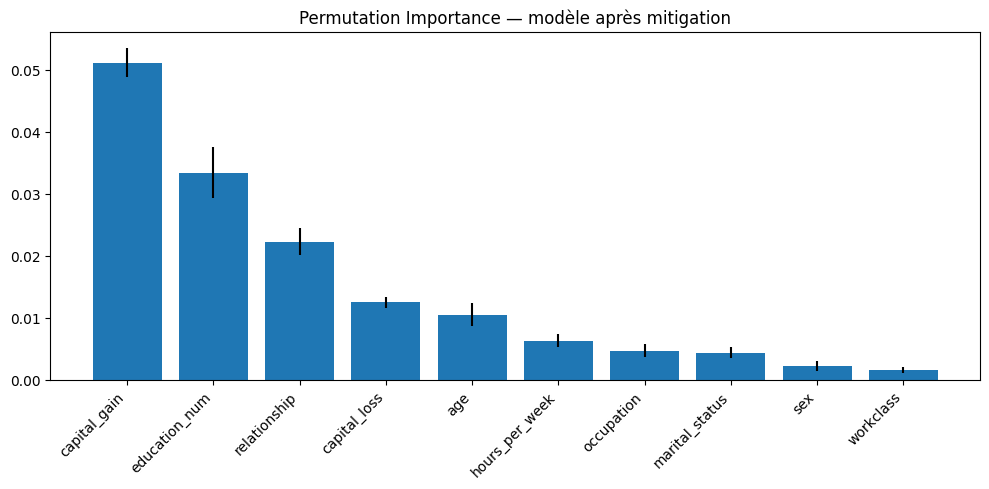

In [ ]:
# Permutation Importance après mitigation

from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

result_mitig = permutation_importance(
    model_mitigated,
    X_ref,
    y_ref,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importances = result_mitig.importances_mean
std = result_mitig.importances_std
features = X_ref.columns

idx = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10,5))
plt.bar(range(len(idx)), importances[idx], yerr=std[idx])
plt.xticks(range(len(idx)), features[idx], rotation=45, ha="right")
plt.title("Permutation Importance — modèle après mitigation")
plt.tight_layout()
plt.show()

/tmp/ipython-input-1131362572.py:37: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


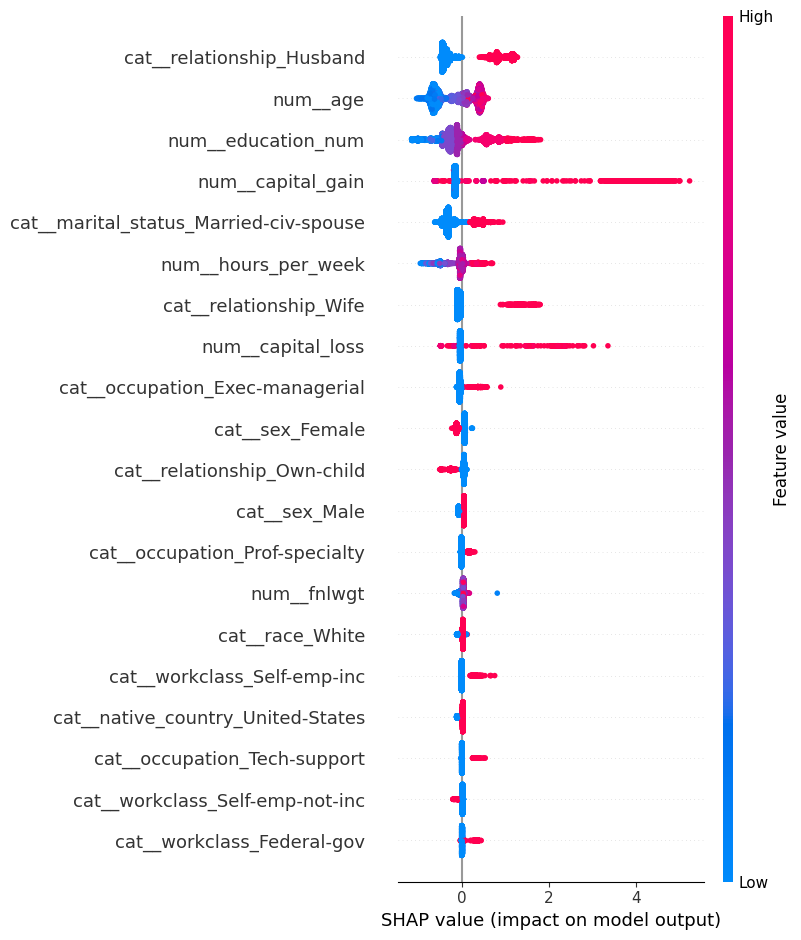

In [ ]:
# SHAP global après mitigation

# === SHAP après mitigation (corrigé pour OneHotEncoder + sparse matrix) ===

import shap
import numpy as np

# Récupérer le modèle mitigé
model_mitigated = model_mix  # modèle réentraîné (stratégie 2)

# Récupérer preprocessing et classifieur
preprocess = model_mitigated.named_steps["preprocessing"]
clf = model_mitigated.named_steps["classifier"]

# Données de référence : test drifté
X_ref = X_test_drift

# Transformation via le preprocessing
X_ref_trans = preprocess.transform(X_ref)

# CORRECTION CLÉ : gérer sparse + dtype
if hasattr(X_ref_trans, "toarray"):
    X_ref_trans = X_ref_trans.toarray()

X_ref_trans = X_ref_trans.astype(float)

# Noms des features après OneHotEncoding
feature_names = preprocess.get_feature_names_out()

# Initialisation SHAP
explainer = shap.TreeExplainer(clf)

# Calcul des valeurs SHAP
shap_values = explainer.shap_values(X_ref_trans)

# Summary plot global
shap.summary_plot(
    shap_values,
    X_ref_trans,
    feature_names=feature_names
)

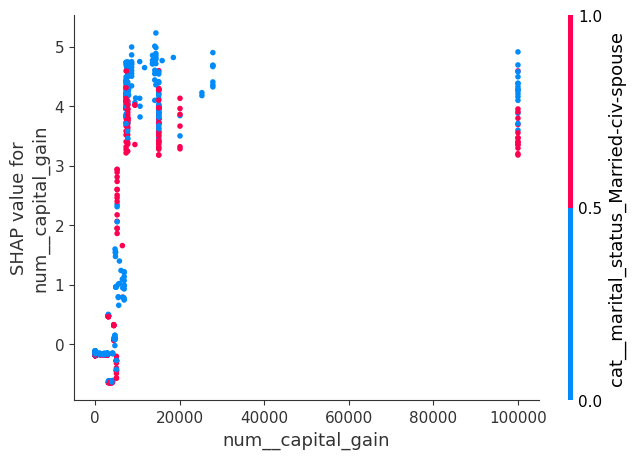

In [ ]:
# Comparaison des dépendances SHAP

# Exemple avec capital_gain
shap.dependence_plot(
    "num__capital_gain",   # nom après ColumnTransformer
    shap_values,
    X_ref_trans,
    feature_names=feature_names
)

In [ ]:
# Explications locales après mitigation

import shap
shap.initjs()

idx = 0  # individu du test drifté

shap.force_plot(
    explainer.expected_value,
    shap_values[idx, :],
    X_ref_trans[idx, :],
    feature_names=feature_names
)